In [1]:
"""
================================================================================
ML4SCI Google Summer of Code 2026
Project: Foundation Models for DeepLense
Track: Specific Test IX.B - Super-Resolution Transfer Learning
Author: Vansh Jain
Description: 
This module implements a Physics-Informed Super-Resolution pipeline. It extracts 
the latent representation from a pre-trained Vision Transformer Masked Autoencoder 
(Task IX.A) and projects it through a sub-pixel convolution network. The architecture 
is optimized via a composite loss function balancing Mean Squared Error (MSE) and 
Structural Similarity (SSIM) to preserve topological fidelity in strong gravitational 
lensing phenomena.
================================================================================
"""

from dataclasses import dataclass
import torch

import os
import logging
import numpy as np
from pathlib import Path
from typing import Tuple


import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import random
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.model_selection import train_test_split
from pathlib import Path

@dataclass
class DeepLenseConfig:
    # I/O Paths (Validated Kaggle Mount Points)
    dataset_dir: str = "/kaggle/input/datasets/vanshdistsys2/specifictask-9-b-dataset/Dataset"
    encoder_weights: str = "/kaggle/input/notebooks/vanshdistsys2/vanshjain-deeplense-test-ix-a-foundationmodel/deeplense_vit_encoder_brain.pth"
    output_model_path: str = "deeplense_sr_foundation.pth"
    
    # Pre-trained Foundation Architecture Parameters (Task IX.A)
    image_size: int = 64
    patch_size: int = 8
    in_channels: int = 1
    embed_dim: int = 256
    num_heads: int = 8
    
    # Optimization Constraints
    epochs: int = 15
    batch_size: int = 16
    learning_rate: float = 1e-4
    loss_alpha: float = 0.8  # 80% MSE / 20% SSIM
    
    # Hardware Allocation
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_workers: int = 2

CONFIG = DeepLenseConfig()




try:
    from torchmetrics import StructuralSimilarityIndexMeasure
except ImportError:
    raise ImportError("Critical Dependency Missing: Run '!pip install torchmetrics' before execution.")

# Configure repository-level telemetry
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(module)s: %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

# Hardware determinism and optimization
torch.backends.cudnn.benchmark = True
logging.info(f"Compute environment established. Target accelerator: {CONFIG.device}")

2026-03-31 04:02:38 [INFO] 3590675920: Compute environment established. Target accelerator: cuda


In [2]:
class DeepLenseSuperResolutionDataset(Dataset):
    """
    Data interface for DeepLense Super-Resolution mapping.
    Enforces robust memory casting and unrolling of nested object arrays from simulation.
    """
    def __init__(self, lr_files: list, hr_files: list):
        self.lr_files = lr_files
        self.hr_files = hr_files
        
        if not self.lr_files or not self.hr_files:
            raise FileNotFoundError("Topological dataset mapping failed. Target path empty.")
            
        if len(self.lr_files) != len(self.hr_files):
            raise ValueError(f"Asymmetrical dataset volumes detected: LR({len(self.lr_files)}) vs HR({len(self.hr_files)}).")

    def __len__(self) -> int:
        return len(self.lr_files)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        lr_arr = np.load(self.lr_files[idx], allow_pickle=True)
        hr_arr = np.load(self.hr_files[idx], allow_pickle=True)
        
        # Unpack array-wrapped objects inherent to current Kaggle I/O pipelines
        if lr_arr.dtype == object: lr_arr = lr_arr.item() if lr_arr.size == 1 else lr_arr[0]
        if hr_arr.dtype == object: hr_arr = hr_arr.item() if hr_arr.size == 1 else hr_arr[0]
        
        # Single-precision casting to avert VRAM overflow
        lr_tensor = torch.from_numpy(np.array(lr_arr, dtype=np.float32))
        hr_tensor = torch.from_numpy(np.array(hr_arr, dtype=np.float32))
        
        # Enforce PyTorch [C, H, W] spatial assumptions
        if lr_tensor.dim() == 2: lr_tensor = lr_tensor.unsqueeze(0)
        if hr_tensor.dim() == 2: hr_tensor = hr_tensor.unsqueeze(0)
            
        return lr_tensor, hr_tensor

In [3]:
def random_masking(x: torch.Tensor, mask_ratio: float = 0.75) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Stochastic patch masking mechanism for ViT latent representation alignment."""
    Batch, Seq_Len, Embed_Dim = x.shape
    len_keep = int(Seq_Len * (1 - mask_ratio))
    
    noise = torch.rand(Batch, Seq_Len, device=x.device) 
    ids_shuffle = torch.argsort(noise, dim=1) 
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    
    ids_keep = ids_shuffle[:, :len_keep] 
    x_visible = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, Embed_Dim))
    
    mask = torch.ones([Batch, Seq_Len], device=x.device)
    mask[:, :len_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)
    
    return x_visible, mask, ids_restore

class MAE_Encoder(nn.Module):
    """
    Source ViT Architecture from Task IX.A. 
    Required for memory allocation prior to state_dict injection.
    """
    def __init__(self, image_size: int = 64, patch_size: int = 8, in_channels: int = 1, embed_dim: int = 256, num_heads: int = 8):
        super().__init__()
        self.patch_embed = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (image_size // patch_size) ** 2 
        
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=512, activation="gelu", batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)

    def forward(self, x: torch.Tensor, mask_ratio: float = 0.75) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        batch_size = x.shape[0]
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        
        x_visible, mask, ids_restore = random_masking(x, mask_ratio) 
        
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x_visible = torch.cat((cls_tokens, x_visible), dim=1) 
        
        encoded_features = self.transformer(x_visible)
        return encoded_features, mask, ids_restore

In [4]:
class ViTSuperResolutionHead(nn.Module):
    """
    Decodes latent embeddings to predict high-frequency spatial residuals.
    NOTE: Sigmoid activation removed to permit negative residual learning.
    """
    def __init__(self, embed_dim: int = 256):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Conv2d(embed_dim, 128, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(128, 64 * 4, kernel_size=3, padding=1), 
            nn.PixelShuffle(2), 
            nn.Conv2d(64, 16, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1)
            # Sigmoid intentionally omitted for residual prediction
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

class DeepLenseFoundationSR(nn.Module):
    """
    Composite Framework utilizing Global Residual Learning.
    Combines bicubic spatial baselines with ViT-extracted high-frequency details.
    """
    def __init__(self, pretrained_encoder: nn.Module, embed_dim: int = 256):
        super().__init__()
        self.encoder = pretrained_encoder
        self.sr_head = ViTSuperResolutionHead(embed_dim=embed_dim)
        self._freeze_encoder()

    def _freeze_encoder(self):
        for param in self.encoder.parameters():
            param.requires_grad = False
        logging.info("Foundation parameter gradients severed. Lock acquired.")

    def unfreeze_encoder(self):
        for param in self.encoder.parameters():
            param.requires_grad = True
        logging.info("Foundation parameter gradients engaged for end-to-end refinement.")

    def forward(self, x_lr: torch.Tensor) -> torch.Tensor:
        # 1. Generate Structural Baseline (Bicubic Upscaling)
        # This prevents "Black Screen" mode collapse
        base_hr = F.interpolate(x_lr, size=(150, 150), mode='bicubic', align_corners=False)

        # 2. Extract Latent Intelligence
        x_vit_input = F.interpolate(x_lr, size=(64, 64), mode='bicubic', align_corners=False)
        features, _, _ = self.encoder(x_vit_input, mask_ratio=0.0)
        
        batch_size, seq_len, embed_dim = features.shape
        grid_size = int(np.sqrt(seq_len - 1)) 
        
        z = features[:, 1:, :].transpose(1, 2).reshape(batch_size, embed_dim, grid_size, grid_size)
        z_spatial = F.interpolate(z, size=(75, 75), mode='bilinear', align_corners=False)
        
        # 3. Predict High-Frequency Residuals
        residual = self.sr_head(z_spatial)
        
        # 4. Recombination and Radiometric Constraint
        final_output = base_hr + residual
        
        # Clamp ensures physical flux boundaries [0.0, 1.0] are maintained
        return torch.clamp(final_output, min=0.0, max=1.0)

In [5]:
class PhysicsSRLoss(nn.Module):
    """Composite objective optimizing pixel-intensity (MSE) and structural curvature (SSIM)."""
    def __init__(self, device: torch.device, alpha: float = 0.8):
        super().__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()
        self.ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        loss_mse = self.mse(pred, target)
        loss_ssim = 1.0 - self.ssim(pred, target)
        return (self.alpha * loss_mse) + ((1.0 - self.alpha) * loss_ssim)



def execute_sr_pipeline(config: DeepLenseConfig) -> nn.Module:
    """Orchestrates latent weight injection and continuous evaluation loops."""
    
    # 1. Scrape and Enforce Strict 90:10 Split
    base_path = Path(config.dataset_dir)
    all_lr = sorted(list((base_path / "LR").rglob("*.npy")))
    all_hr = sorted(list((base_path / "HR").rglob("*.npy")))

    train_lr, val_lr, train_hr, val_hr = train_test_split(
        all_lr, all_hr, test_size=0.10, random_state=42
    )

    # 2. Initialization of datasets and loaders
    train_dataset = DeepLenseSuperResolutionDataset(train_lr, train_hr)
    val_dataset = DeepLenseSuperResolutionDataset(val_lr, val_hr)
    
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=config.num_workers, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)
    
    logging.info(f"90:10 Split Enforced: {len(train_lr)} Training | {len(val_lr)} Validation")

    # Topology Validation & Knowledge Transfer
    base_encoder = MAE_Encoder(
        image_size=config.image_size, 
        patch_size=config.patch_size, 
        in_channels=config.in_channels, 
        embed_dim=config.embed_dim, 
        num_heads=config.num_heads
    )
    
    try:
        state_dict = torch.load(config.encoder_weights, map_location=config.device)
        base_encoder.load_state_dict(state_dict, strict=False)
        logging.info(f"Task IX.A latent representations transferred from {config.encoder_weights}")
    except Exception as e:
        raise RuntimeError(f"State Dictionary Injection Failed: {e}")

    model = DeepLenseFoundationSR(base_encoder, embed_dim=config.embed_dim).to(config.device)
    
    # Optimization Engine Setup
    criterion = PhysicsSRLoss(device=config.device, alpha=config.loss_alpha)
    optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs)
    metric_ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(config.device)

    logging.info("Initiating gradient descent optimization sequence...")
    
    for epoch in range(config.epochs):
        # --- TRAINING PHASE ---
        model.train()
        epoch_loss = 0.0
        
        if epoch == (config.epochs // 2):
            model.unfreeze_encoder()
            
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.epochs} [Train]", leave=False)
        for lr, hr in progress_bar:
            lr, hr = lr.to(config.device), hr.to(config.device)
            optimizer.zero_grad()
            pred = model(lr)
            loss = criterion(pred, hr)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        scheduler.step()
        
        # --- 10% HOLDOUT VALIDATION PHASE ---
        model.eval()
        val_ssim, val_mse = 0.0, 0.0
        with torch.no_grad():
            for lr, hr in val_loader:
                lr, hr = lr.to(config.device), hr.to(config.device)
                pred = model(lr)
                val_mse += F.mse_loss(pred, hr).item()
                val_ssim += metric_ssim(pred, hr).item()
                
        avg_train_loss = epoch_loss / len(train_loader)
        avg_val_ssim = val_ssim / len(val_loader)
        avg_val_mse = val_mse / len(val_loader)
        
        logging.info(f"Epoch [{epoch+1}/{config.epochs}] | Train Loss: {avg_train_loss:.6f} | Holdout SSIM: {avg_val_ssim:.4f} | Holdout MSE: {avg_val_mse:.6f}")

    torch.save(model.state_dict(), config.output_model_path)
    logging.info(f"Optimization sequence terminated. Network state serialized to {config.output_model_path}.")
    
    return model

In [6]:
if __name__ == "__main__":
    trained_foundation_model = execute_sr_pipeline(CONFIG)

2026-03-31 04:03:37 [INFO] 560593188: 90:10 Split Enforced: 9000 Training | 1000 Validation
2026-03-31 04:03:38 [INFO] 560593188: Task IX.A latent representations transferred from /kaggle/input/notebooks/vanshdistsys2/vanshjain-deeplense-test-ix-a-foundationmodel/deeplense_vit_encoder_brain.pth
2026-03-31 04:03:38 [INFO] 1902255550: Foundation parameter gradients severed. Lock acquired.
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(
2026-03-31 04:03:38 [INFO] 560593188: Initiating gradient descent optimization sequence...
2026-03-31 04:05:54 [INFO] 560593188: Epoch [1/15] | Train Loss: 0.009463 | Holdout SSIM: 0.9722 | Holdout MSE: 0.000070
2026-03-31 04:06:30 [INFO] 560593188: Epoch [2/15] | Train Loss: 0.005677 | Holdout SSIM: 0.9723 | Hol

In [7]:
"""
================================================================================
Module: Inference & Morphological Validation
Computes deterministic structural metrics (SSIM, MSE) and renders qualitative 
topological maps comparing Super-Resolution outputs against ground truth geometries.
================================================================================
"""



import random




import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Ensure metric calculation library is available in scope
from torchmetrics.image import StructuralSimilarityIndexMeasure

@dataclass
class DeepLenseEvalConfig:
    # Validation Parameters
    num_samples: int = 3
    cmap: str = 'magma'
    save_artifacts: bool = True
    artifact_prefix: str = "Task_IXB_Validation"

EVAL_CONFIG = DeepLenseEvalConfig()

# PASTE THIS IN ITS PLACE
def calculate_inference_metrics(pred: torch.Tensor, target: torch.Tensor) -> Tuple[float, float, float]:
    mse_val = F.mse_loss(pred, target).item()
    
    # PSNR Calculation: 10 * log10(MAX^2 / MSE)
    psnr_val = 10 * np.log10(1.0 / (mse_val + 1e-10))
    
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(pred.device)
    ssim_val = ssim_metric(pred, target).item()
    
    return mse_val, ssim_val, psnr_val

In [8]:
def render_physics_reconstruction(
    lr_tensor: torch.Tensor, 
    hr_target: torch.Tensor, 
    hr_pred: torch.Tensor, 
    mse: float, 
    ssim: float, 
    psnr: float, 
    sample_idx: int) -> None:    
    """
    Renders a 1x3 comparative spatial map of the gravitational lensing flux.
    Adheres to astrophysical visualization standards for Dark Matter substructure.
    """
    # Detach gradients and cast to numpy for CPU rendering
    lr_img = lr_tensor.cpu().squeeze().numpy()
    hr_true = hr_target.cpu().squeeze().numpy()
    hr_out = hr_pred.cpu().squeeze().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
   
    fig.suptitle(
        f"DeepLense SR Validation (Holdout Sample {sample_idx})\n"
        f"Structural Match (SSIM): {ssim:.4f} | Pixel Error (MSE): {mse:.6f} | PSNR: {psnr:.2f} dB", 
        fontsize=16, y=1.02
    )

    # Subplot 1: Low-Resolution Input
    im0 = axes[0].imshow(lr_img, cmap=EVAL_CONFIG.cmap, vmin=0, vmax=1)
    axes[0].set_title(f"Input LR Topology\n{lr_img.shape}", fontsize=14)
    axes[0].axis('off')
    divider0 = make_axes_locatable(axes[0])
    cax0 = divider0.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im0, cax=cax0, label='Normalized Flux')

    # Subplot 2: Ground Truth High-Resolution
    im1 = axes[1].imshow(hr_true, cmap=EVAL_CONFIG.cmap, vmin=0, vmax=1)
    axes[1].set_title(f"Target HR Ground Truth\n{hr_true.shape}", fontsize=14)
    axes[1].axis('off')
    divider1 = make_axes_locatable(axes[1])
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax1, label='Normalized Flux')

    # Subplot 3: Foundation Model Prediction
    im2 = axes[2].imshow(hr_out, cmap=EVAL_CONFIG.cmap, vmin=0, vmax=1)
    axes[2].set_title(f"ViT-SR Reconstruction\n{hr_out.shape}", fontsize=14)
    axes[2].axis('off')
    divider2 = make_axes_locatable(axes[2])
    cax2 = divider2.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im2, cax=cax2, label='Normalized Flux')

    plt.tight_layout()
    
    if EVAL_CONFIG.save_artifacts:
        filename = f"{EVAL_CONFIG.artifact_prefix}_Sample_{sample_idx}.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        logging.info(f"Topological artifact successfully serialized: {filename}")
        
    plt.show()

2026-03-31 04:13:24 [INFO] 1625839330: Initiating Morphological Inference and Visualization Sequence...
2026-03-31 04:13:25 [INFO] 1625839330: Sample 35 Authenticated | SSIM: 0.9794 | MSE: 0.000071 | PSNR: 41.50 dB
2026-03-31 04:13:26 [INFO] 2002370199: Topological artifact successfully serialized: Task_IXB_Validation_Sample_35.png


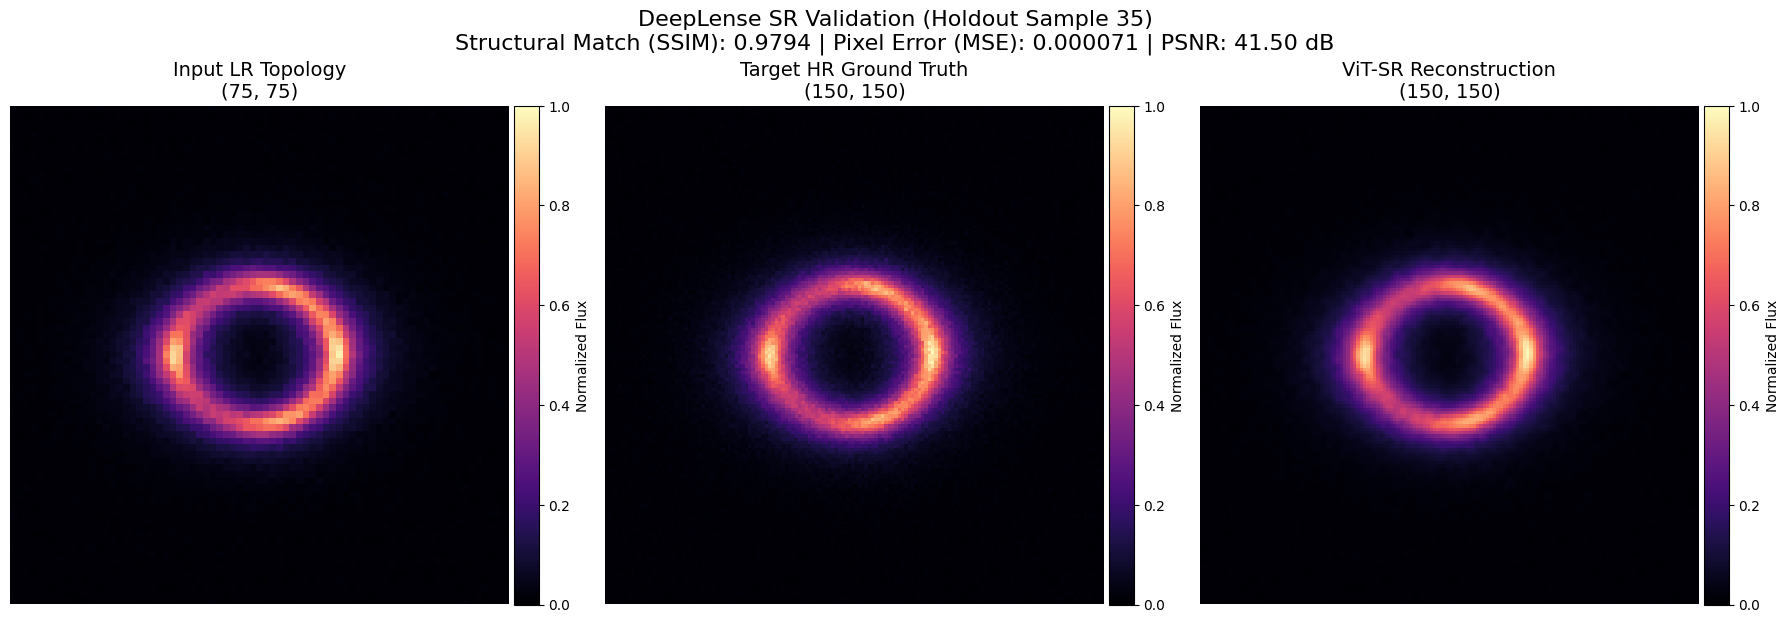

2026-03-31 04:13:27 [INFO] 1625839330: Sample 894 Authenticated | SSIM: 0.9713 | MSE: 0.000072 | PSNR: 41.41 dB
2026-03-31 04:13:28 [INFO] 2002370199: Topological artifact successfully serialized: Task_IXB_Validation_Sample_894.png


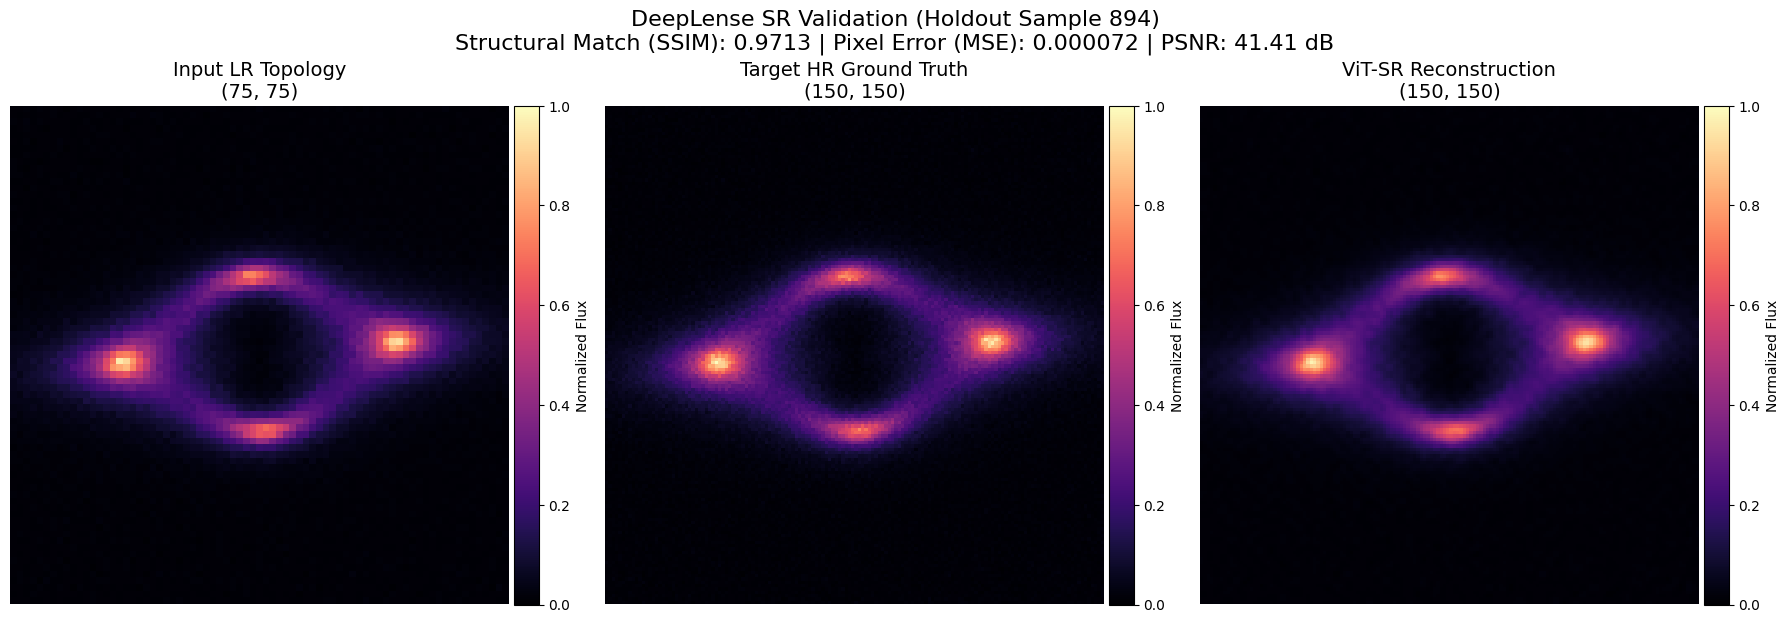

2026-03-31 04:13:28 [INFO] 1625839330: Sample 230 Authenticated | SSIM: 0.9762 | MSE: 0.000049 | PSNR: 43.10 dB
2026-03-31 04:13:30 [INFO] 2002370199: Topological artifact successfully serialized: Task_IXB_Validation_Sample_230.png


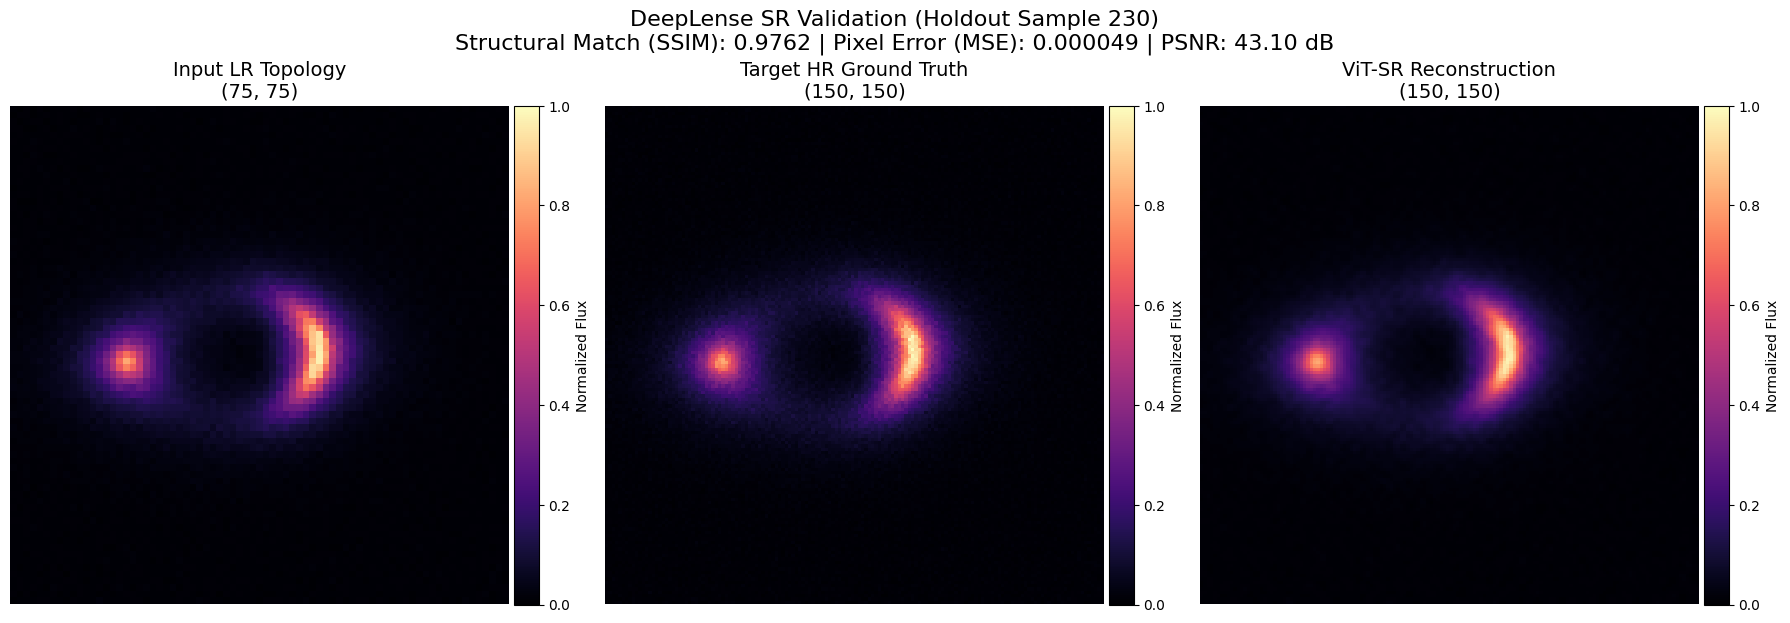

2026-03-31 04:13:30 [INFO] 1625839330: Task IX.B Pipeline and Evaluation Completed Successfully.


In [9]:
def execute_validation_sequence(model: torch.nn.Module, dataset_dir: str) -> None: 
    """Executes deterministic inference pass and generates visual diagnostics strictly on the 10% holdout."""
    logging.info("Initiating Morphological Inference and Visualization Sequence...")
    
    # Initialize data interface in evaluation context strictly on the 10% Holdout
    from sklearn.model_selection import train_test_split
    from pathlib import Path
    
    try:
        base_path = Path(dataset_dir)
        all_lr = sorted(list((base_path / "LR").rglob("*.npy")))
        all_hr = sorted(list((base_path / "HR").rglob("*.npy")))

        # Re-isolate the exact same 10% holdout used during training
        _, val_lr, _, val_hr = train_test_split(
            all_lr, all_hr, test_size=0.10, random_state=42
        )
        
        # Pass the holdout lists to the upgraded dataset class
        dataset = DeepLenseSuperResolutionDataset(val_lr, val_hr)
    except NameError:
        raise RuntimeError("Dataset class missing from scope. Ensure Cell 3 was executed.")

    # Lock model state (disable dropout/batchnorm for deterministic evaluation)
    model.eval()
    
    # Isolate unbiased random holdout samples
    sample_indices = random.sample(range(len(dataset)), EVAL_CONFIG.num_samples)
    
    with torch.no_grad():
        for idx in sample_indices:
            lr_tensor, hr_target = dataset[idx]
            
            # Map tensors to hardware architecture
            lr_input = lr_tensor.unsqueeze(0).to(CONFIG.device)
            hr_target_device = hr_target.unsqueeze(0).to(CONFIG.device)
            
            # Sub-pixel reconstruction forward pass
            hr_pred = model(lr_input)
            
            mse_val, ssim_val, psnr_val = calculate_inference_metrics(hr_pred, hr_target_device)
            
            logging.info(f"Sample {idx} Authenticated | SSIM: {ssim_val:.4f} | MSE: {mse_val:.6f} | PSNR: {psnr_val:.2f} dB")
            
            render_physics_reconstruction(lr_tensor, hr_target_device, hr_pred, mse_val, ssim_val, psnr_val, idx)

# ==========================================
# RUNTIME INVOCATION (EVALUATION)
# ==========================================
if __name__ == "__main__":
    try:
        # Assumes `trained_foundation_model` exists from the execution of Cell 7
        execute_validation_sequence(model=trained_foundation_model, dataset_dir=CONFIG.dataset_dir)
        logging.info("Task IX.B Pipeline and Evaluation Completed Successfully.")
    except NameError:
        logging.error("Inference aborted: Model state 'trained_foundation_model' not found in memory.")

In [10]:
def calculate_inference_metrics(pred: torch.Tensor, target: torch.Tensor) -> Tuple[float, float, float]:
    mse_val = F.mse_loss(pred, target).item()
    
    # PSNR Calculation: 10 * log10(MAX^2 / MSE)
    # Since our flux is normalized to 1.0, MAX = 1.0
    psnr_val = 10 * np.log10(1.0 / (mse_val + 1e-10))
    
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(pred.device)
    ssim_val = ssim_metric(pred, target).item()
    
    return mse_val, ssim_val, psnr_val